# 07 · Inference — Healthy Reconstruction on BraTS

Loads trained BraTS 2020 T1 volumes, preprocesses them with the same pipeline
used during training, loads the `diffusion_epoch0030.pt` checkpoint, and
sets up the full anomaly-detection inference pipeline.

```
BraTS T1 slice  x₀
      │
      ▼  (synthetic centre mask — replace with ACAT later)
DDIM encode  →  x_L      (forward noise inside mask)
      │
      ▼
Hybrid decode  →  x̂₀   (DDPM inside mask · DDIM outside)
      │
      ▼
Anomaly map  =  |x₀ − x̂₀|
```

**Notebook sections**
1. Imports & paths
2. `preprocess_volume` (identical to training)
3. BraTS dataset — returns T1 slices + segmentation masks
4. DataLoader sanity checks
5. Model definition & checkpoint loading
6. Schedulers
7. Inference functions (`ddim_encode`, `hybrid_decode`, `anomaly_map`)

## 1 · Imports & paths

In [40]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDIMScheduler, DDPMScheduler

# ── reproducibility ─────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ── device ───────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')

# ── paths ────────────────────────────────────────────────────────────────
def _find_dir(name):
    for p in [Path.cwd(), *Path.cwd().parents]:
        c = p / name
        if c.is_dir():
            return c
    raise FileNotFoundError(f"Cannot find '{name}' — run from inside the Brats folder.")

BRATS_ROOT  = _find_dir('BraTS2020_TrainingData') / 'MICCAI_BraTS2020_TrainingData'
LOG_DIR     = Path.cwd() / 'logs'
CKPT_PATH   = Path.cwd() / 'diffusion_best_e0077.pt'   # trained from nb06

assert BRATS_ROOT.is_dir(),  f'BraTS root not found: {BRATS_ROOT}'
assert CKPT_PATH.is_file(),  f'Checkpoint not found: {CKPT_PATH}'

print(f'BraTS root : {BRATS_ROOT}')
print(f'Checkpoint : {CKPT_PATH}  ({CKPT_PATH.stat().st_size / 1e6:.0f} MB)')

Device : cpu
BraTS root : c:\Users\ayush\Downloads\Brats\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
Checkpoint : c:\Users\ayush\Downloads\Brats\diffusion_best_e0077.pt  (515 MB)


## 2 · `preprocess_volume` — identical to training

Must match `04_thin_slice_preprocessing.ipynb` / `06_train_from_scratch.ipynb` exactly:
- Percentile normalisation on non-zero voxels → [0, 1]
- Z-range filter: keep 15%–85% of depth
- Fill filter: discard slices with < 5% non-zero pixels
- Bilinear resize to 256 × 256

For BraTS we also preprocess the **segmentation** volume (no normalisation —
just slice and keep as integer labels).

In [41]:
def preprocess_volume(nii_path, target_size=256,
                      z_low=0.15, z_high=0.85, fill_thresh=0.05):
    """
    Preprocess a T1w NIfTI volume into a list of 2D slice tensors.
    Matches training pipeline exactly.

    Returns
    -------
    slices : list of np.ndarray  shape (1, target_size, target_size), float32, [0,1]
    z_indices : list of int  — original z-index for each returned slice
    """
    vol = nib.load(str(nii_path)).get_fdata(dtype=np.float32)
    if vol.ndim != 3:
        return [], []

    nonzero = vol[vol != 0]
    if nonzero.size == 0:
        return [], []

    # percentile normalisation
    p_lo, p_hi = np.percentile(nonzero, [0.5, 99.5])
    vol = np.clip((vol - p_lo) / max(float(p_hi - p_lo), 1e-6), 0.0, 1.0)

    D = vol.shape[2]
    z0 = int(np.floor(D * z_low))
    z1 = int(min(np.ceil(D * z_high), D))

    slices, z_indices = [], []
    for zi in range(z0, z1):
        s = vol[:, :, zi]
        if np.count_nonzero(s) / s.size < fill_thresh:
            continue
        if s.shape[0] != target_size or s.shape[1] != target_size:
            t = torch.from_numpy(s[None, None])
            s = F.interpolate(t, (target_size, target_size),
                              mode='bilinear', align_corners=False).squeeze().numpy()
        slices.append(s[np.newaxis].astype(np.float32))   # (1, H, W)
        z_indices.append(zi)

    return slices, z_indices


def preprocess_seg(seg_path, z_indices, target_size=256):
    """
    Extract segmentation slices at the same z-indices returned by preprocess_volume.
    Labels: 0=background, 1=necrotic, 2=edema, 3=enhancing tumour.

    Returns
    -------
    seg_slices : list of np.ndarray  shape (1, target_size, target_size), int32
    """
    vol = nib.load(str(seg_path)).get_fdata(dtype=np.float32).astype(np.int32)
    seg_slices = []
    for zi in z_indices:
        s = vol[:, :, zi]
        if s.shape[0] != target_size or s.shape[1] != target_size:
            t = torch.from_numpy(s[None, None].astype(np.float32))
            s = F.interpolate(t, (target_size, target_size),
                              mode='nearest').squeeze().numpy().astype(np.int32)
        seg_slices.append(s[np.newaxis])   # (1, H, W)
    return seg_slices


print('preprocess_volume and preprocess_seg defined.')

preprocess_volume and preprocess_seg defined.


## 3 · BraTS dataset

Each BraTS case folder contains:
```
BraTS20_Training_XXX/
    *_t1.nii      ← we use this modality (matches MR-RATE T1w training)
    *_seg.nii     ← ground-truth tumour labels
    *_t1ce.nii    (ignored)
    *_t2.nii      (ignored)
    *_flair.nii   (ignored)
```

`BraTSDataset` returns **all valid slices** per case (unlike the training
dataset which returns one random slice per epoch). Each item is a dict:
```python
{
    'image'  : Tensor (1, 256, 256) float32  — normalised T1 slice
    'seg'    : np.ndarray (1, 256, 256) int32 — label map
    'case'   : str   — e.g. 'BraTS20_Training_001'
    'z_idx'  : int   — original z-index in the volume
    'has_tumor': bool — True if any non-zero seg label in this slice
}
```

In [42]:
def discover_brats_cases(brats_root):
    """
    Discover all BraTS cases that have both a T1 and a segmentation file.

    Returns
    -------
    cases : list of dict  keys: id, t1_path, seg_path
    """
    cases = []
    for case_dir in sorted(Path(brats_root).iterdir()):
        if not case_dir.is_dir():
            continue
        t1_files  = list(case_dir.glob('*_t1.nii'))
        seg_files = list(case_dir.glob('*_seg.nii'))
        if not t1_files or not seg_files:
            continue
        cases.append(dict(
            id       = case_dir.name,
            t1_path  = t1_files[0],
            seg_path = seg_files[0],
        ))
    return cases


class BraTSDataset(Dataset):
    """
    Flat dataset: one item per valid axial slice across all BraTS cases.
    Preprocessing is lazy (per-__getitem__) to stay RAM-friendly.

    Parameters
    ----------
    cases       : list of dicts from discover_brats_cases()
    tumor_only  : if True, only return slices that contain tumour voxels
    """

    def __init__(self, cases, tumor_only=False):
        self.tumor_only = tumor_only
        # build flat index: list of (case_dict, z_idx)
        print(f'Indexing {len(cases)} BraTS cases (lazy — fast) ...')
        self._index = []          # filled on first __len__ / __getitem__ call
        self._cases = cases
        self._indexed = False

    def _build_index(self):
        """Walk all volumes and record (case, z_idx, has_tumor) for every valid slice."""
        self._index = []
        for case in self._cases:
            slices, z_idxs = preprocess_volume(case['t1_path'])
            if not slices:
                continue
            seg_slices = preprocess_seg(case['seg_path'], z_idxs)
            for sl, seg, zi in zip(slices, seg_slices, z_idxs):
                has_tumor = bool(seg.max() > 0)
                if self.tumor_only and not has_tumor:
                    continue
                self._index.append(dict(
                    case=case, z_idx=zi,
                    has_tumor=has_tumor,
                ))
        self._indexed = True
        print(f'Index built: {len(self._index)} slices '
              f'({sum(e["has_tumor"] for e in self._index)} with tumour)')

    def __len__(self):
        if not self._indexed:
            self._build_index()
        return len(self._index)

    def __getitem__(self, idx):
        if not self._indexed:
            self._build_index()
        entry = self._index[idx]
        case  = entry['case']
        zi    = entry['z_idx']

        # re-load the single slice we need
        slices, z_idxs = preprocess_volume(case['t1_path'])
        pos = z_idxs.index(zi)
        image_arr = slices[pos]                           # (1, 256, 256) float32

        seg_slices = preprocess_seg(case['seg_path'], [zi])
        seg_arr    = seg_slices[0]                        # (1, 256, 256) int32

        return {
            'image'    : torch.from_numpy(image_arr),
            'seg'      : seg_arr,
            'case'     : case['id'],
            'z_idx'    : zi,
            'has_tumor': entry['has_tumor'],
        }


print('BraTSDataset defined.')

BraTSDataset defined.


## 4 · DataLoader sanity checks

We load only a handful of cases for a quick sanity check rather than indexing
all 371 upfront (that takes several minutes). Set `N_CASES = None` to use all.

In [43]:
# ── discover all cases ───────────────────────────────────────────────────
all_cases = discover_brats_cases(BRATS_ROOT)
print(f'Found {len(all_cases)} BraTS cases')
print(f'Example: {all_cases[0]["id"]}')
print(f'  T1  : {all_cases[0]["t1_path"].name}')
print(f'  Seg : {all_cases[0]["seg_path"].name}')

Found 368 BraTS cases
Example: BraTS20_Training_001
  T1  : BraTS20_Training_001_t1.nii
  Seg : BraTS20_Training_001_seg.nii


In [44]:
# ── quick sanity check: preprocess one case ──────────────────────────────
case0 = all_cases[0]
slices0, z0 = preprocess_volume(case0['t1_path'])
segs0       = preprocess_seg(case0['seg_path'], z0)

print(f'Case  : {case0["id"]}')
print(f'Valid slices : {len(slices0)}  (from z={z0[0]} to z={z0[-1]})')
print(f'Slice shape  : {slices0[0].shape}  dtype={slices0[0].dtype}')
print(f'Seg   shape  : {segs0[0].shape}    dtype={segs0[0].dtype}')
print(f'Seg labels present : {np.unique(np.concatenate([s.flatten() for s in segs0]))}')
tumor_slices = sum(1 for s in segs0 if s.max() > 0)
print(f'Slices with tumour : {tumor_slices} / {len(segs0)}')

Case  : BraTS20_Training_001
Valid slices : 107  (from z=23 to z=129)
Slice shape  : (1, 256, 256)  dtype=float32
Seg   shape  : (1, 256, 256)    dtype=int32
Seg labels present : [0 1 2 4]
Slices with tumour : 83 / 107


The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


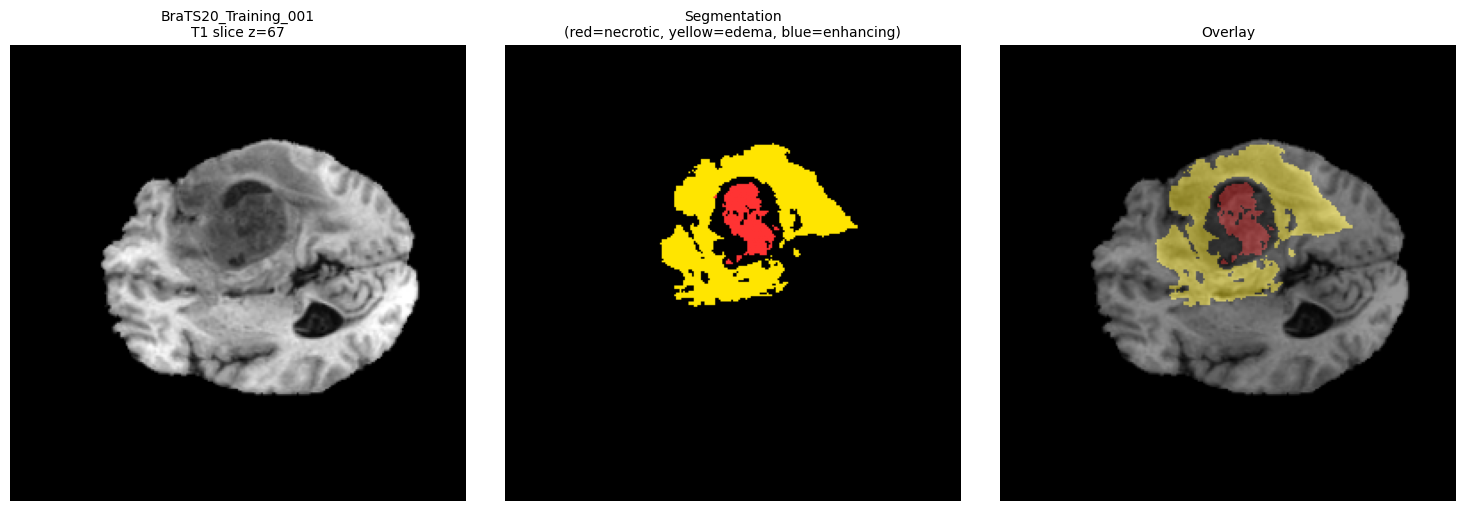

Slice shown: z=67  tumour voxels=5725


In [45]:
# ── visualise one T1 slice alongside its seg mask ───────────────────────
# pick the most tumour-heavy slice for a clear visualisation
tumor_load  = [s.sum() for s in segs0]
best_z      = int(np.argmax(tumor_load))

t1_slice  = slices0[best_z][0]    # (256, 256)
seg_slice = segs0[best_z][0]      # (256, 256)

# colour map: 0=bg (black), 1=necrotic (red), 2=edema (yellow), 3=enhancing (blue)
cmap_seg = plt.cm.get_cmap('tab10', 4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(t1_slice, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'{case0["id"]}\nT1 slice z={z0[best_z]}', fontsize=10)

seg_rgb = np.zeros((*seg_slice.shape, 3))
seg_rgb[seg_slice == 1] = [1.0, 0.2, 0.2]   # necrotic — red
seg_rgb[seg_slice == 2] = [1.0, 0.9, 0.0]   # edema — yellow
seg_rgb[seg_slice == 3] = [0.2, 0.4, 1.0]   # enhancing — blue
axes[1].imshow(seg_rgb)
axes[1].set_title('Segmentation\n(red=necrotic, yellow=edema, blue=enhancing)', fontsize=10)

axes[2].imshow(t1_slice, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(seg_rgb, alpha=0.4)
axes[2].set_title('Overlay', fontsize=10)

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Slice shown: z={z0[best_z]}  tumour voxels={int((seg_slice > 0).sum())}')

In [46]:
# ── build a small dataset + DataLoader for 5 cases ───────────────────────
# (use all_cases for full inference; 5 here just for speed)
N_CASES = 5
demo_cases = all_cases[:N_CASES]

demo_dataset = BraTSDataset(demo_cases, tumor_only=False)

# custom collate: seg and metadata can't stack by default
def brats_collate(batch):
    return {
        'image'    : torch.stack([b['image'] for b in batch]),
        'seg'      : np.stack([b['seg'] for b in batch]),
        'case'     : [b['case'] for b in batch],
        'z_idx'    : [b['z_idx'] for b in batch],
        'has_tumor': [b['has_tumor'] for b in batch],
    }

demo_loader = DataLoader(
    demo_dataset,
    batch_size  = 4,
    shuffle     = False,
    num_workers = 0,        # Windows-safe
    collate_fn  = brats_collate,
)

# pull one batch and verify shapes
batch = next(iter(demo_loader))
print(f'image shape : {batch["image"].shape}   dtype={batch["image"].dtype}')
print(f'seg   shape : {batch["seg"].shape}      dtype={batch["seg"].dtype}')
print(f'cases       : {batch["case"]}')
print(f'z_indices   : {batch["z_idx"]}')
print(f'has_tumor   : {batch["has_tumor"]}')
print(f'image range : [{batch["image"].min():.3f}, {batch["image"].max():.3f}]')

Indexing 5 BraTS cases (lazy — fast) ...
Index built: 541 slices (309 with tumour)
image shape : torch.Size([4, 1, 256, 256])   dtype=torch.float32
seg   shape : (4, 1, 256, 256)      dtype=int32
cases       : ['BraTS20_Training_001', 'BraTS20_Training_001', 'BraTS20_Training_001', 'BraTS20_Training_001']
z_indices   : [23, 24, 25, 26]
has_tumor   : [False, False, False, False]
image range : [0.000, 0.780]


## 5 · Model definition & checkpoint loading

Architecture must match `06_train_from_scratch.ipynb` exactly:

| Param | Value |
|-------|-------|
| `channels` | (64, 128, 256, 256) |
| `attention_levels` | (False, False, False, True) |
| `num_res_blocks` | 2 |
| `num_head_channels` | 32 |

Checkpoint key: `'unet'`  (saved as full model state dict).

In [47]:
# ── instantiate model (must match training architecture) ─────────────────────
# NOTE: this architecture (out_channels=2, channels=(128,256,256,512)) is
# for checkpoints trained with the updated 06_train_from_scratch.ipynb.
# If you only have diffusion_epoch0030.pt (out_channels=1, channels=(64,128,256,256))
# set out_channels=1 and channels=(64,128,256,256) to load that checkpoint.


unet = DiffusionModelUNet(
    spatial_dims      = 2,
    in_channels       = 1,
    out_channels      = 1,
    channels          = (64, 128, 256, 512),   # grow at deeper levels only
    attention_levels  = (False, False, False, True),  # attention only at 32px
    num_res_blocks    = 1,                     # keep at 1
    num_head_channels = 32,
    norm_num_groups   = 32,
).to(DEVICE)


total_params = sum(p.numel() for p in unet.parameters())
print(f'Model instantiated — {total_params/1e6:.2f} M parameters')

# ── load checkpoint ──────────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)

missing, unexpected = unet.load_state_dict(ckpt['unet'], strict=True)
if missing:
    print(f'WARNING — missing keys  : {missing[:5]}')
if unexpected:
    print(f'WARNING — unexpected keys: {unexpected[:5]}')

unet.eval()
print(f'Checkpoint loaded — epoch {ckpt["epoch"]}')

# checkpoint may have train_losses (old) or train_mse_losses (new)
mse_key = 'train_mse_losses' if 'train_mse_losses' in ckpt else 'train_losses'
print(f'Final train MSE : {ckpt[mse_key][-1]:.6f}')
print(f'Final val   MSE : {ckpt["val_losses"][-1]:.6f}')


Model instantiated — 42.86 M parameters
Checkpoint loaded — epoch 77
Final train MSE : 0.003221
Final val   MSE : 0.016541


In [48]:
# ── quick forward-pass smoke test ────────────────────────────────────────────
with torch.no_grad():
    x_test = torch.randn(1, 1, 256, 256).to(DEVICE)
    t_test = torch.tensor([500], device=DEVICE).long()
    out    = unet(x_test, t_test)                      # (1, 2, 256, 256)
print(f'Forward pass OK — output shape: {out.shape}  dtype: {out.dtype}')
print(f'  noise_pred  : {out[:, :1].shape}')
print(f'  log_var     : {out[:, 1:].shape}')


Forward pass OK — output shape: torch.Size([1, 1, 256, 256])  dtype: torch.float32
  noise_pred  : torch.Size([1, 1, 256, 256])
  log_var     : torch.Size([1, 0, 256, 256])


## 6 · Schedulers

Same config as training: linear-beta schedule, T=1000.
- `ddpm_scheduler` — used for inside-mask stochastic decode
- `ddim_scheduler` — used for DDIM encode and outside-mask deterministic decode

In [49]:
T = 1000

ddpm_scheduler = DDPMScheduler(
    num_train_timesteps = T,
    schedule            = 'linear_beta',
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)

ddim_scheduler = DDIMScheduler(
    num_train_timesteps = T,
    schedule            = 'linear_beta',
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)

print(f'DDPM scheduler: T={T}')
print(f'DDIM scheduler: T={T}')

DDPM scheduler: T=1000
DDIM scheduler: T=1000


## 7 · Inference functions

Three functions implement the full anomaly-detection pipeline.

### `ddim_encode`
One-shot forward noise to timestep `L` using the scheduler's `add_noise`.
Applied only inside the mask; healthy regions keep their original pixel values.

### `hybrid_decode`
Reverse from `t=L` down to `t=0`:
- **Inside mask** — DDPM step (stochastic → generates healthy anatomy)
- **Outside mask** — DDIM step (deterministic → preserves healthy anatomy)

At each step the clean region is re-pasted at the current noise level to
prevent the model from hallucinating anatomy outside the mask.

### `anomaly_map`
Pixel-wise `|x₀ − x̂₀|` with optional Gaussian smoothing.

In [50]:
@torch.no_grad()
def ddim_encode(x0: torch.Tensor, mask: torch.Tensor,
                scheduler: DDIMScheduler,
                encode_timestep: int = 500) -> torch.Tensor:
    """
    Forward encode x0 -> x_L inside the mask region.
    """
    noise    = torch.randn_like(x0)
    t_tensor = torch.tensor([encode_timestep], device=x0.device).long()
    x_noised = scheduler.add_noise(x0, noise, t_tensor)
    x_L      = x0 * (1 - mask) + x_noised * mask
    return x_L


@torch.no_grad()
def hybrid_decode(x_L: torch.Tensor, x0_orig: torch.Tensor,
                  mask: torch.Tensor,
                  unet: nn.Module,
                  ddpm_sched: DDPMScheduler,
                  ddim_sched: DDIMScheduler,
                  start_t: int = 500,
                  n_ddim_steps: int = 50):
    """
    Hybrid DDPM/DDIM reverse decode from t=start_t down to t=0.

    Inside  mask (M=1) : DDPM step -- stochastic, regenerates healthy anatomy
    Outside mask (M=0) : DDIM step -- deterministic, preserves healthy anatomy

    Returns
    -------
    x_hat         : (1,1,256,256) healthy reconstruction
    uncertainty   : (256,256) np.ndarray  ones placeholder (model has out_channels=1)
    """
    unet.eval()
    ddim_sched.set_timesteps(n_ddim_steps)
    timesteps = [t for t in ddim_sched.timesteps if t <= start_t]

    x = x_L.clone()

    # uncertainty not available with out_channels=1 -- use ones placeholder
    uncertainty = np.ones((x_L.shape[2], x_L.shape[3]), dtype=np.float32)

    # -- reverse decode ----------------------------------------------------
    for t_val in timesteps:
        t_batch    = torch.tensor([t_val], device=x.device).long()
        noise_pred = unet(x, t_batch)                       # (1,1,256,256)

        x_ddpm = ddpm_sched.step(noise_pred, t_val, x)[0]
        x_ddim = ddim_sched.step(noise_pred, t_val, x)[0]

        x = x_ddim * (1 - mask) + x_ddpm * mask

        t_tensor = torch.tensor([t_val], device=x.device).long()
        x_orig_t = ddpm_sched.add_noise(x0_orig, torch.randn_like(x0_orig), t_tensor)
        x        = x_orig_t * (1 - mask) + x * mask

    return x.clamp(0.0, 1.0), uncertainty


def anomaly_map(x0: torch.Tensor, x_hat: torch.Tensor,
                smooth_sigma: float = 2.0) -> torch.Tensor:
    """
    Pixel-wise anomaly score: |x0 - x_hat|, optionally Gaussian-smoothed.
    Returns (1,1,256,256) float32 on CPU.
    """
    diff = (x0 - x_hat).abs().cpu()
    if smooth_sigma > 0:
        k   = max(3, int(smooth_sigma * 3) | 1)
        pad = k // 2
        kernel = torch.ones(1, 1, 1, k) / k
        diff   = F.conv2d(F.conv2d(diff, kernel, padding=(0, pad)),
                          kernel.transpose(-1, -2), padding=(pad, 0))
    return diff


print("ddim_encode, hybrid_decode, anomaly_map defined.")


ddim_encode, hybrid_decode, anomaly_map defined.


## 8 · Demo — pipeline on a tumour slice with synthetic mask

We pick the most tumour-heavy slice from the first BraTS case and use
the **ground-truth segmentation** as the mask (binary: any tumour label → 1).
This is the ideal mask; in practice it will come from the ACAT classifier.

In [51]:
# ── pick a random tumour-containing slice from a random case ─────────────────
DEMO_CASE_IDX  = random.randint(0, len(all_cases) - 1)   # change to a fixed int to pin a case

demo_case = all_cases[DEMO_CASE_IDX]
slices0, z0 = preprocess_volume(demo_case['t1_path'])
segs0        = preprocess_seg(demo_case['seg_path'], z0)

# prefer a tumour slice; fall back to most-filled slice if case has no tumour
tumor_loads = [s.sum() for s in segs0]
tumor_idxs  = [i for i, s in enumerate(segs0) if s.max() > 0]
if tumor_idxs:
    best_z = tumor_idxs[int(np.argmax([tumor_loads[i] for i in tumor_idxs]))]
else:
    best_z = int(np.argmax([sl.mean() for sl in slices0]))
    print('No tumour in this case — picking most-filled slice')

x0_np  = slices0[best_z]     # (1, 256, 256) float32
seg_np = segs0[best_z]       # (1, 256, 256) int32

x0_demo = torch.from_numpy(x0_np)[None].to(DEVICE)    # (1,1,256,256)

# binary mask from ground-truth seg
mask_gt = torch.from_numpy((seg_np > 0).astype(np.float32))[None].to(DEVICE)
if mask_gt.sum() == 0:
    print('No tumour — using synthetic centre mask')
    mask_gt = torch.zeros_like(x0_demo)
    mask_gt[:, :, 96:160, 96:160] = 1.0

print(f'Case : {demo_case["id"]}  (index {DEMO_CASE_IDX}/{len(all_cases)-1})')
print(f'Slice: z={z0[best_z]}  tumour_voxels={int((seg_np > 0).sum())}')

ENCODE_T = 500
N_STEPS  = 50

# ── run the pipeline ──────────────────────────────────────────────────────────
x_L              = ddim_encode(x0_demo, mask_gt, ddim_scheduler, encode_timestep=ENCODE_T)
x_hat, uncert    = hybrid_decode(x_L, x0_demo, mask_gt, unet,
                                 ddpm_scheduler, ddim_scheduler,
                                 start_t=ENCODE_T, n_ddim_steps=N_STEPS)
a_map            = anomaly_map(x0_demo, x_hat, smooth_sigma=2.0)

# ── combined anomaly score ────────────────────────────────────────────────────
recon_anom  = a_map[0, 0].numpy()          # (256,256)
combined    = recon_anom * uncert          # (256,256)

print(f'x0   : {x0_demo.shape}  [{x0_demo.min():.3f}, {x0_demo.max():.3f}]')
print(f'x_hat: {x_hat.shape}  [{x_hat.min():.3f}, {x_hat.max():.3f}]')
print(f'amap : {a_map.shape}   [{a_map.min():.4f}, {a_map.max():.4f}]')
print(f'uncert shape: {uncert.shape}   [{uncert.min():.4f}, {uncert.max():.4f}]')
print(f'combined     [{combined.min():.4f}, {combined.max():.4f}]')


Case : BraTS20_Training_328  (index 327/367)
Slice: z=89  tumour_voxels=7331
x0   : torch.Size([1, 1, 256, 256])  [0.000, 1.000]
x_hat: torch.Size([1, 1, 256, 256])  [0.000, 1.000]
amap : torch.Size([1, 1, 256, 256])   [0.0007, 0.7330]
uncert shape: (256, 256)   [1.0000, 1.0000]
combined     [0.0007, 0.7330]


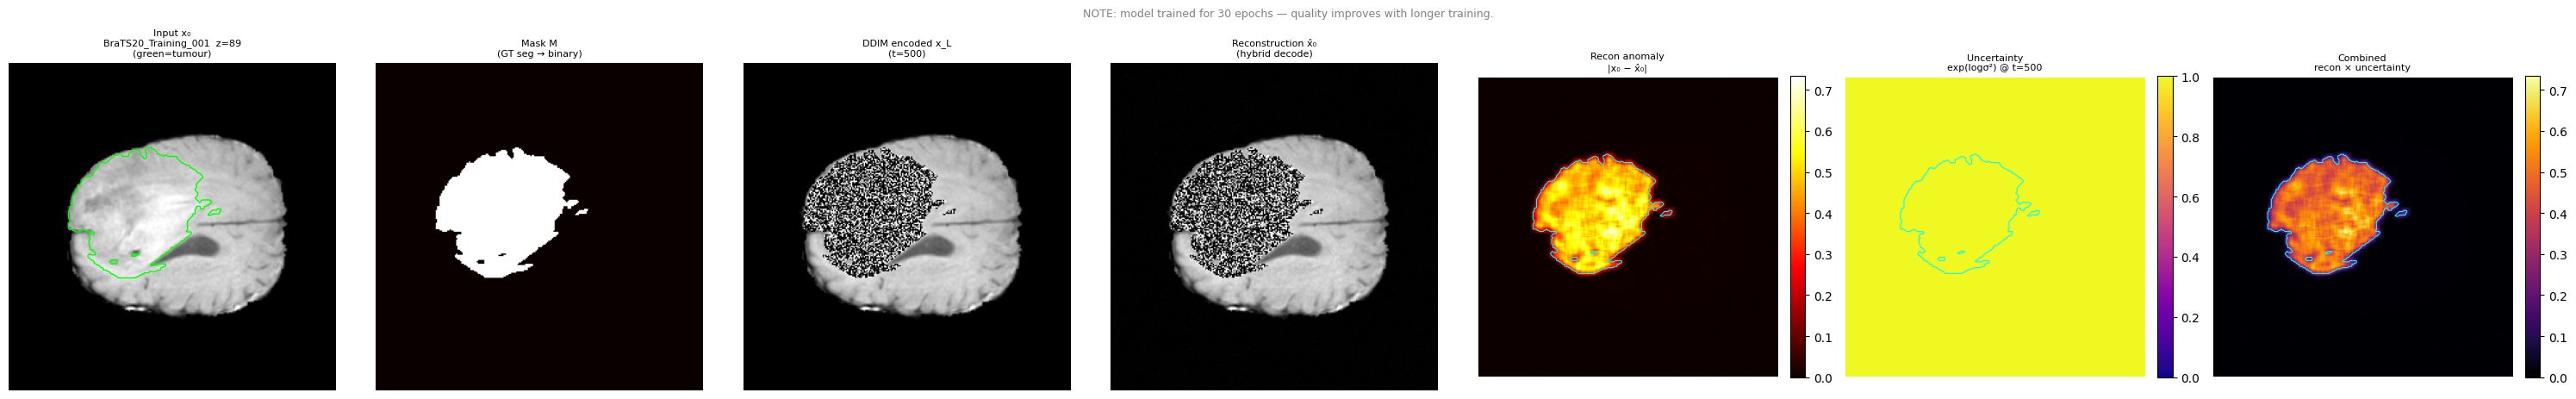

Saved → logs/figures/07_demo_brats_inference.png


In [52]:
# ── visualise (7 panels) ──────────────────────────────────────────────────────
seg_np_plot  = seg_np[0]                         # (256,256) int32
mask_binary  = (seg_np_plot > 0).astype(np.float32)

fig, axes = plt.subplots(1, 7, figsize=(30, 5))

# 0 — input with tumour contour
axes[0].imshow(x0_demo[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].contour(mask_binary, levels=[0.5], colors='lime', linewidths=1)
axes[0].set_title(f'Input x₀\n{case0["id"]}  z={z0[best_z]}\n(green=tumour)', fontsize=8)

# 1 — binary mask
axes[1].imshow(mask_gt[0, 0].cpu().numpy(), cmap='hot')
axes[1].set_title('Mask M\n(GT seg → binary)', fontsize=8)

# 2 — DDIM encoded
axes[2].imshow(x_L[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'DDIM encoded x_L\n(t={ENCODE_T})', fontsize=8)

# 3 — reconstruction
axes[3].imshow(x_hat[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[3].set_title('Reconstruction x̂₀\n(hybrid decode)', fontsize=8)

# 4 — reconstruction anomaly
im4 = axes[4].imshow(recon_anom, cmap='hot', vmin=0)
axes[4].contour(mask_binary, levels=[0.5], colors='cyan', linewidths=0.8)
axes[4].set_title('Recon anomaly\n|x₀ − x̂₀|', fontsize=8)
fig.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

# 5 — uncertainty map
im5 = axes[5].imshow(uncert, cmap='plasma', vmin=0)
axes[5].contour(mask_binary, levels=[0.5], colors='cyan', linewidths=0.8)
axes[5].set_title(f'Uncertainty\nexp(logσ²) @ t={ENCODE_T}', fontsize=8)
fig.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

# 6 — combined score
im6 = axes[6].imshow(combined, cmap='inferno', vmin=0)
axes[6].contour(mask_binary, levels=[0.5], colors='cyan', linewidths=0.8)
axes[6].set_title('Combined\nrecon × uncertainty', fontsize=8)
fig.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

fig.suptitle(
    'NOTE: model trained for 30 epochs — quality improves with longer training.',
    fontsize=9, color='gray'
)
plt.tight_layout()
(LOG_DIR / 'figures').mkdir(parents=True, exist_ok=True)
fig.savefig(LOG_DIR / 'figures' / '07_demo_brats_inference.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → logs/figures/07_demo_brats_inference.png')


## 9 · Unconditional generation — brain from pure noise

Run the full DDIM reverse process starting from pure Gaussian noise .
No input image, no mask — the model generates a brain slice from scratch.
This is the best probe of what the model has actually learnt:
- Good anatomy → model has internalised healthy brain structure
- Blurry / incoherent → needs more training epochs

In [ ]:
N_SAMPLES    = 1     # how many independent brains to generate
N_GEN_STEPS  = 1000   # DDIM steps (more = sharper, slower)

gen_scheduler = DDIMScheduler(
    num_train_timesteps = T,
    schedule            = 'linear_beta',
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)
gen_scheduler.set_timesteps(N_GEN_STEPS)

unet.eval()

@torch.no_grad()
def generate_from_noise(n_samples=1, n_steps=100, seed=None):
    """
    Unconditional DDIM sampling: x_T -> x_0.

    Returns
    -------
    samples : (n_samples, 1, 256, 256) float32 tensor on CPU, values in [0,1]
    """
    if seed is not None:
        torch.manual_seed(seed)

    x = torch.randn(n_samples, 1, 256, 256, device=DEVICE)   # pure Gaussian noise

    for t_val in gen_scheduler.timesteps:                     # T-1 ... 0
        t_batch    = torch.full((n_samples,), t_val, device=DEVICE, dtype=torch.long)
        noise_pred = unet(x, t_batch)
        x          = gen_scheduler.step(noise_pred, t_val, x)[0]

    return x.clamp(0.0, 1.0).cpu()


samples = generate_from_noise(n_samples=N_SAMPLES, n_steps=N_GEN_STEPS, seed=0)
print(f'Generated {N_SAMPLES} samples — shape: {samples.shape}  '
      f'range: [{samples.min():.3f}, {samples.max():.3f}]')

# ── visualise ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, N_SAMPLES, figsize=(5 * N_SAMPLES, 5))

if N_SAMPLES == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.imshow(samples[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Sample {i+1}(seed=0, step={i})', fontsize=10)
    ax.axis('off')

fig.suptitle(
    f'Unconditional brain generation — {N_GEN_STEPS}-step DDIM from pure noise\n'
    f'epoch 30 checkpoint (quality improves with longer training)',
    fontsize=10
)

plt.tight_layout()

fig.savefig(LOG_DIR / 'figures' / '07_unconditional_samples.png', dpi=150, bbox_inches='tight')

plt.show()

print('Saved → logs/figures/07_unconditional_samples.png')

## 10 · Full-image denoising — brain from a noised BraTS sample

Different from both the masked pipeline and unconditional generation:
- Take a **real BraTS T1 slice** `x0`
- Corrupt the **entire image** (no mask) to noise level `DENOISE_T`
- Run DDIM reverse on the whole noised image back to `t=0`

This checks whether the model can round-trip a real brain slice
without any inpainting guidance — a proxy for how well it has
learnt healthy anatomy rather than just memorising noise patterns.

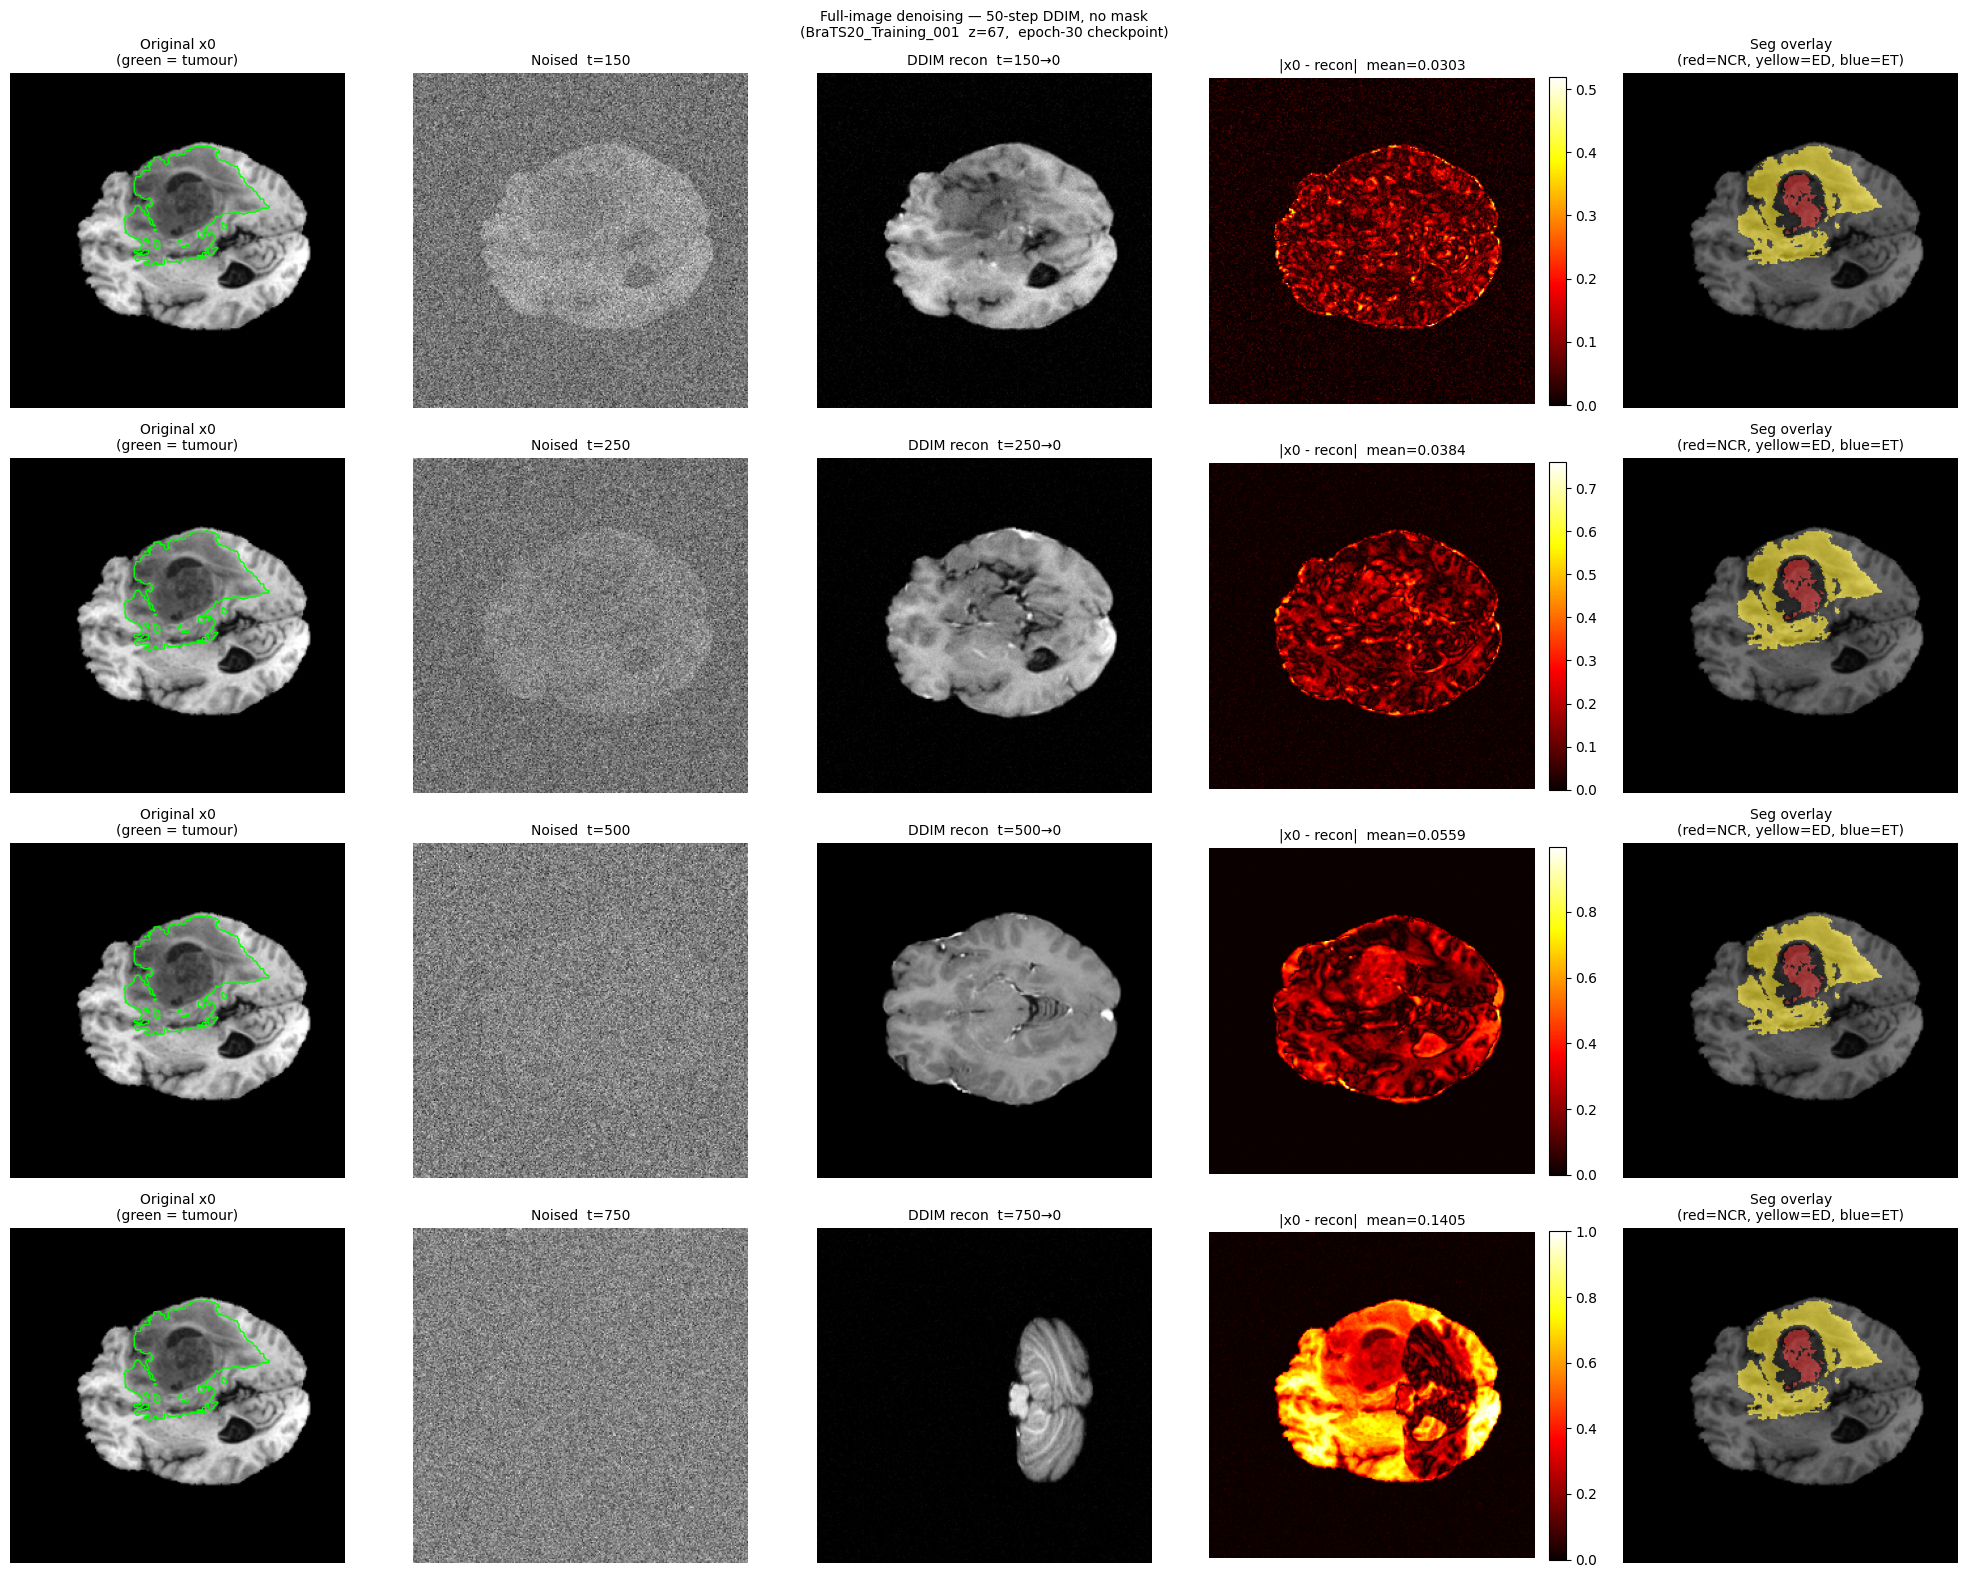

Saved → logs/figures/07_fullimage_denoise.png


In [ ]:
DENOISE_T   = 500   # noise level — try 250 / 500 / 750
N_DEN_STEPS = 50    # DDIM decode steps

den_scheduler = DDIMScheduler(
    num_train_timesteps = T,
    schedule            = "linear_beta",
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)
den_scheduler.set_timesteps(N_DEN_STEPS)


@torch.no_grad()
def denoise_from_noised_sample(x0, encode_t, n_steps=50):
    """
    Noise the full image to timestep encode_t, then DDIM-decode
    back to t=0 with no mask.

    Parameters
    ----------
    x0       : (1,1,256,256) clean slice on DEVICE
    encode_t : int  noise level to corrupt to
    n_steps  : int  DDIM reverse steps

    Returns
    -------
    x_noised : (1,1,256,256) the corrupted image
    x_recon  : (1,1,256,256) the decoded reconstruction
    """
    # ── forward: noise entire image ──────────────────────────────────────
    noise    = torch.randn_like(x0)
    t_tensor = torch.tensor([encode_t], device=x0.device).long()
    x_noised = ddpm_scheduler.add_noise(x0, noise, t_tensor)

    # ── reverse: DDIM decode from encode_t -> 0, no mask ─────────────────
    den_scheduler.set_timesteps(n_steps)
    timesteps = [t for t in den_scheduler.timesteps if t <= encode_t]

    x = x_noised.clone()
    for t_val in timesteps:
        t_batch    = torch.tensor([t_val], device=x.device).long()
        noise_pred = unet(x, t_batch)     # (1,1,256,256)
        x          = den_scheduler.step(noise_pred, t_val, x)[0]

    return x_noised, x.clamp(0.0, 1.0)


# ── pre-build the seg RGB overlay (same for every row) ───────────────────
seg_np_plot = segs0[best_z][0]   # (256, 256) int32
seg_rgb_plot = np.zeros((*seg_np_plot.shape, 3))
seg_rgb_plot[seg_np_plot == 1] = [1.0, 0.2, 0.2]   # necrotic — red
seg_rgb_plot[seg_np_plot == 2] = [1.0, 0.9, 0.0]   # edema — yellow
seg_rgb_plot[seg_np_plot == 3] = [0.2, 0.4, 1.0]   # enhancing — blue

x0_np_plot  = x0_demo[0, 0].cpu().numpy()           # (256, 256)
mask_binary = (seg_np_plot > 0).astype(np.float32)  # (256, 256)

# ── sweep three noise levels ─────────────────────────────────────────────
# 5 columns: original+contour | noised | recon | |x0-recon| | seg overlay
noise_levels = [150,250, 500, 750]
NCOLS = 5
fig, axes = plt.subplots(len(noise_levels), NCOLS,
                         figsize=(NCOLS * 4, 4 * len(noise_levels)))

for row, enc_t in enumerate(noise_levels):
    xn, xr = denoise_from_noised_sample(x0_demo, enc_t, N_DEN_STEPS)
    res     = (x0_demo - xr).abs().cpu()

    # col 0 — original T1 with tumour contour
    axes[row, 0].imshow(x0_np_plot, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].contour(mask_binary, levels=[0.5], colors="lime", linewidths=1)
    axes[row, 0].set_title("Original x0\n(green = tumour)", fontsize=10)

    # col 1 — noised image
    axes[row, 1].imshow(xn[0, 0].cpu().numpy(), cmap="gray")
    axes[row, 1].set_title(f"Noised  t={enc_t}", fontsize=10)

    # col 2 — DDIM reconstruction
    axes[row, 2].imshow(xr[0, 0].cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[row, 2].set_title(f"DDIM recon  t={enc_t}\u21920", fontsize=10)

    # col 3 — residual |x0 - recon|
    im = axes[row, 3].imshow(res[0, 0].numpy(), cmap="hot", vmin=0)
    axes[row, 3].set_title(f"|x0 - recon|  mean={res.mean():.4f}", fontsize=10)
    fig.colorbar(im, ax=axes[row, 3], fraction=0.046, pad=0.04)

    # col 4 — seg mask overlay on original
    axes[row, 4].imshow(x0_np_plot, cmap="gray", vmin=0, vmax=1)
    axes[row, 4].imshow(seg_rgb_plot, alpha=0.5)
    axes[row, 4].set_title("Seg overlay\n(red=NCR, yellow=ED, blue=ET)", fontsize=10)

for ax in axes.flat:
    ax.axis("off")

fig.suptitle(
    f"Full-image denoising — {N_DEN_STEPS}-step DDIM, no mask\n"
    f"({case0['id']}  z={z0[best_z]},  epoch-30 checkpoint)",
    fontsize=10
)
plt.tight_layout()
fig.savefig(LOG_DIR / "figures" / "07_fullimage_denoise.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved \u2192 logs/figures/07_fullimage_denoise.png")

## Next steps

| Step | Task |
|------|------|
| **08** | Batch inference over all 371 BraTS cases; save anomaly maps |
| **09** | Evaluate against ground-truth seg: Dice, AUC-ROC, AUPRC |
| **ACAT** | Replace synthetic/GT mask with ACAT classifier saliency map |
| **Tune** | Sweep `ENCODE_T` ∈ {250, 500, 750} and `smooth_sigma` ∈ {1, 2, 4} |
| **Train more** | Resume training from this checkpoint; target 500–1000 epochs |